# 11-5. 셀 단위 종일 승차인원 변화량 OLS

분석 단위는 250m 격자 132개이며, 종속변수는 각 셀의 분석대상 서울행 광역버스 전체를 합산한 `2025년 종일 승차인원 - 2024년 종일 승차인원`이다.

보행시간만 세 가지 방식으로 바꾸고 IC 도로거리, 셀 단위 GTX 경쟁 목적지 비율, 2024년 20~50대 인구, 건축물 수는 동일하게 유지한다. 표준오차는 이분산에 강건한 HC3를 사용한다.

- 모형 1: GTX역 보행시간 연속형(분)
- 모형 2: GTX역 보행 20분 이내 더미 하나(기준: 20분 초과)
- 모형 3: 20분 이내·20~60분 더미(기준: 60분 초과)

In [2]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from config import *
setup_notebook()

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display

ID = '셀 ID'
SHARE_SOURCE = 'GTX 경쟁 목적지 승차인원 비율(%)'
COMPETING_CELL_PATH = PROCESSED_DIR / '06_GTX_경쟁목적지비율_종일_셀.csv'

base = load_model_data()
comp = read_csv(COMPETING_CELL_PATH)
comp[ID] = pd.to_numeric(comp[ID], errors='coerce').astype('Int64')
comp = comp[[ID, SHARE_SOURCE]].rename(columns={SHARE_SOURCE: 'competing_share'})

model = base.merge(comp, on=ID, how='left', validate='one_to_one')
model['change_all'] = pd.to_numeric(model['change_all'], errors='coerce')
model['walk_20_only'] = (model['walk_min'] <= 20).astype(float)

common = ['ic_access', 'competing_share', 'pop_20_50', 'buildings']
required = ['change_all', 'walk_min', 'walk_20', 'walk_20_60'] + common
for column in required:
    model[column] = pd.to_numeric(model[column], errors='coerce')
model = model.dropna(subset=required).copy()

print('분석 셀 수:', len(model))
print('셀 ID 중복:', model[ID].duplicated().sum())
print('종속변수: 2025년 종일 승차인원 - 2024년 종일 승차인원')
display(model[[ID, 'change_all', 'walk_min', 'walk_20', 'walk_20_60'] + common].head())

분석 셀 수: 132
셀 ID 중복: 0
종속변수: 2025년 종일 승차인원 - 2024년 종일 승차인원


,셀 ID,change_all,walk_min,walk_20,walk_20_60,ic_access,competing_share,pop_20_50,buildings
0,44,-105,51.650000,0.0,1.0,5.071,21.189591,937.0,18.0
1,76,18,160.710000,0.0,0.0,1.921,0.000000,33.0,37.0
2,559,8,50.225000,0.0,1.0,0.319,0.000000,0.0,46.0
3,619,3,166.555000,0.0,0.0,9.029,100.000000,0.0,7.0
4,765,7,128.416667,0.0,0.0,4.323,38.888889,139.0,92.0


## 1. 세 가지 OLS 추정

In [3]:
specs = {
    '모형1_보행시간_연속형': ['walk_min'] + common,
    '모형2_20분이내_더미': ['walk_20_only'] + common,
    '모형3_3구간_더미': ['walk_20', 'walk_20_60'] + common,
}

fits = {}
for name, features in specs.items():
    X = sm.add_constant(model[features].astype(float), has_constant='add')
    fits[name] = sm.OLS(model['change_all'], X).fit(cov_type='HC3')
    print('\n' + '=' * 90)
    print(name)
    print(fits[name].summary())


모형1_보행시간_연속형
                            OLS Regression Results                            
Dep. Variable:             change_all   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     2.225
Date:                Tue, 06 Oct 2026   Prob (F-statistic):             0.0558
Time:                        23:15:01   Log-Likelihood:                -780.97
No. Observations:                 132   AIC:                             1574.
Df Residuals:                     126   BIC:                             1591.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -71.6979  

## 2. 모형 적합도 비교

In [4]:
comparison = pd.DataFrame([
    {
        '모형': name,
        '표본 수': int(fit.nobs),
        'R²': fit.rsquared,
        '수정 R²': fit.rsquared_adj,
        'AIC': fit.aic,
        'BIC': fit.bic,
        '모형 전체 p값': fit.f_pvalue,
        'RMSE': np.sqrt(np.mean(fit.resid ** 2)),
    }
    for name, fit in fits.items()
])
display(comparison.round(4))

,모형,표본 수,R²,수정 R²,AIC,BIC,모형 전체 p값,RMSE
0,모형1_보행시간_연속형,132,0.0768,0.0401,1573.9385,1591.2353,0.0558,89.7919
1,모형2_20분이내_더미,132,0.1248,0.0901,1566.8804,1584.1772,0.1823,87.4231
2,모형3_3구간_더미,132,0.1614,0.1212,1563.2436,1583.4232,0.0109,85.5763


## 3. 핵심 변수 계수와 p값 비교

In [5]:
labels = {
    'walk_min': 'GTX역 보행시간(분)',
    'walk_20_only': 'GTX역 보행 20분 이내(기준: 20분 초과)',
    'walk_20': 'GTX역 보행 20분 이내(기준: 60분 초과)',
    'walk_20_60': 'GTX역 보행 20~60분(기준: 60분 초과)',
    'ic_access': 'IC까지 도로거리(km)',
    'competing_share': 'GTX 경쟁 목적지 비율(%)',
    'pop_20_50': '2024년 20~50대 인구(명)',
    'buildings': '2024년 건축물 수(동)',
}

rows = []
for name, fit in fits.items():
    ci = fit.conf_int()
    for variable in specs[name]:
        rows.append({
            '모형': name,
            '변수': labels[variable],
            '계수(명)': fit.params[variable],
            'HC3 표준오차': fit.bse[variable],
            't값': fit.tvalues[variable],
            'p값': fit.pvalues[variable],
            '95% CI 하한': ci.loc[variable, 0],
            '95% CI 상한': ci.loc[variable, 1],
        })
result_table = pd.DataFrame(rows)
display(result_table.round(4))

,모형,변수,계수(명),HC3 표준오차,t값,p값,95% CI 하한,95% CI 상한
0,모형1_보행시간_연속형,GTX역 보행시간(분),0.5604,0.1836,3.0520,0.0023,0.2005,0.9203
1,모형1_보행시간_연속형,IC까지 도로거리(km),-1.4324,2.6149,-0.5478,0.5838,-6.5575,3.6926
2,모형1_보행시간_연속형,GTX 경쟁 목적지 비율(%),-0.4288,0.2821,-1.5200,0.1285,-0.9817,0.1241
3,모형1_보행시간_연속형,2024년 20~50대 인구(명),0.0233,0.0179,1.3025,0.1927,-0.0118,0.0585
4,모형1_보행시간_연속형,2024년 건축물 수(동),0.1355,0.2348,0.5772,0.5638,-0.3246,0.5957
5,모형2_20분이내_더미,GTX역 보행 20분 이내(기준: 20분 초과),-113.7349,56.8390,-2.0010,0.0454,-225.1374,-2.3324
6,모형2_20분이내_더미,IC까지 도로거리(km),0.8300,2.2910,0.3623,0.7171,-3.6604,5.3204
7,모형2_20분이내_더미,GTX 경쟁 목적지 비율(%),-0.2160,0.2625,-0.8230,0.4105,-0.7305,0.2984
8,모형2_20분이내_더미,2024년 20~50대 인구(명),0.0074,0.0162,0.4574,0.6474,-0.0244,0.0393
9,모형2_20분이내_더미,2024년 건축물 수(동),0.2891,0.2103,1.3744,0.1693,-0.1232,0.7014


## 해석 주의사항

- 계수의 단위는 **셀 전체 승차 변화량의 명(人) 차이**이다.
- 모형 2에서 20분 이내 계수는 20분 초과 셀과의 평균 변화량 차이다.
- 모형 3에서 두 보행시간 계수의 공통 기준은 60분 초과 셀이다.
- 이 모형에는 2024년 승차인원을 통제변수로 넣지 않았으므로 지역별 기존 승차규모 차이가 계수에 함께 반영될 수 있다. 2024년 승차규모 통제 모형은 별도의 강건성 분석으로 비교하는 것이 안전하다.

## 4. 기본모형: 보행시간 3구간 더미

세 모형 중 적합도와 해석 가능성을 고려해 3구간 더미 모형을 기본모형으로 지정한다. 60분 초과 셀이 기준집단이다.

In [6]:
BASE_FEATURES = ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'pop_20_50', 'buildings']
X_base = sm.add_constant(model[BASE_FEATURES].astype(float), has_constant='add')
base_fit = sm.OLS(model['change_all'], X_base).fit(cov_type='HC3')
print(base_fit.summary())

base_ci = base_fit.conf_int().loc[BASE_FEATURES]
base_result = pd.DataFrame({
    '변수': [labels[v] for v in BASE_FEATURES],
    '계수(명)': [base_fit.params[v] for v in BASE_FEATURES],
    'HC3 표준오차': [base_fit.bse[v] for v in BASE_FEATURES],
    't값': [base_fit.tvalues[v] for v in BASE_FEATURES],
    'p값': [base_fit.pvalues[v] for v in BASE_FEATURES],
    '95% CI 하한': [base_ci.loc[v, 0] for v in BASE_FEATURES],
    '95% CI 상한': [base_ci.loc[v, 1] for v in BASE_FEATURES],
})
display(base_result.round(4))

                            OLS Regression Results                            
Dep. Variable:             change_all   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     2.908
Date:                Tue, 06 Oct 2026   Prob (F-statistic):             0.0109
Time:                        23:15:01   Log-Likelihood:                -774.62
No. Observations:                 132   AIC:                             1563.
Df Residuals:                     125   BIC:                             1583.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.0851     25.841     

,변수,계수(명),HC3 표준오차,t값,p값,95% CI 하한,95% CI 상한
0,GTX역 보행 20분 이내(기준: 60분 초과),-147.0818,56.4156,-2.6071,0.0091,-257.6543,-36.5092
1,GTX역 보행 20~60분(기준: 60분 초과),-44.5802,14.6153,-3.0502,0.0023,-73.2256,-15.9348
2,IC까지 도로거리(km),-2.1017,2.4882,-0.8447,0.3983,-6.9785,2.7751
3,GTX 경쟁 목적지 비율(%),-0.2907,0.2657,-1.0941,0.2739,-0.8114,0.2300
4,2024년 20~50대 인구(명),0.0182,0.0163,1.1168,0.2641,-0.0138,0.0502
5,2024년 건축물 수(동),0.2569,0.2083,1.2333,0.2174,-0.1513,0.6651


## 5. 2024년 공시지가 추가 비교

공시지가는 GTX 개통 전 지역의 토지가치·개발 수준을 통제하는 변수로 사용한다. 원값은 `100만원/㎡` 단위로 바꾸어 해석하고, 분포의 비대칭을 줄이기 위해 자연로그 버전도 별도로 비교한다. 두 값을 동시에 넣지는 않는다.

In [7]:
LAND_PATH = PROCESSED_DIR / '12_공시지가_2024_250m격자.csv'
LAND_RAW = '2024년 공시지가(원/㎡)'
LAND_LOG = 'log_2024년 공시지가'

land = read_csv(LAND_PATH)
land[ID] = pd.to_numeric(land[ID], errors='coerce').astype('Int64')
land[LAND_RAW] = pd.to_numeric(land[LAND_RAW], errors='coerce')
land[LAND_LOG] = pd.to_numeric(land[LAND_LOG], errors='coerce')
land['land_price_million'] = land[LAND_RAW] / 1_000_000

model_land = model.merge(
    land[[ID, 'land_price_million', LAND_LOG]],
    on=ID, how='left', validate='one_to_one'
)

# 세 모형을 같은 130개 셀에서 비교해야 AIC·BIC 비교가 가능하다.
common_land_sample = model_land.dropna(
    subset=['change_all'] + BASE_FEATURES + ['land_price_million', LAND_LOG]
).copy()

land_specs = {
    '기본모형': BASE_FEATURES,
    '공시지가_원값_100만원단위': BASE_FEATURES + ['land_price_million'],
    '공시지가_자연로그': BASE_FEATURES + [LAND_LOG],
}
land_fits = {}
for name, features in land_specs.items():
    sample = common_land_sample.copy()
    X = sm.add_constant(sample[features].astype(float), has_constant='add')
    land_fits[name] = sm.OLS(sample['change_all'], X).fit(cov_type='HC3')

land_comparison = []
for name, fit in land_fits.items():
    land_variable = None if name == '기본모형' else land_specs[name][-1]
    land_comparison.append({
        '모형': name,
        '표본 수': int(fit.nobs),
        'R²': fit.rsquared,
        '수정 R²': fit.rsquared_adj,
        'AIC': fit.aic,
        'BIC': fit.bic,
        '공시지가 계수': np.nan if land_variable is None else fit.params[land_variable],
        '공시지가 p값': np.nan if land_variable is None else fit.pvalues[land_variable],
    })
display(pd.DataFrame(land_comparison).round(4))

for name, fit in land_fits.items():
    if name == '기본모형':
        continue
    print('\n' + '=' * 80)
    print(name)
    key_variables = BASE_FEATURES + [land_specs[name][-1]]
    display(pd.DataFrame({
        '계수': fit.params.loc[key_variables],
        'HC3 표준오차': fit.bse.loc[key_variables],
        'p값': fit.pvalues.loc[key_variables],
    }).round(4))

,모형,표본 수,R²,수정 R²,AIC,BIC,공시지가 계수,공시지가 p값
0,기본모형,130,0.1594,0.1184,1541.7419,1561.8147,NaN,NaN
1,공시지가_원값_100만원단위,130,0.1635,0.1155,1543.0951,1566.0354,9.7011,0.7676
2,공시지가_자연로그,130,0.1625,0.1145,1543.2555,1566.1958,9.9294,0.6456



공시지가_원값_100만원단위


,계수,HC3 표준오차,p값
walk_20,-145.9241,56.4998,0.0098
walk_20_60,-48.2288,18.1671,0.0079
ic_access,-1.6875,2.5049,0.5005
competing_share,-0.2906,0.2799,0.2991
pop_20_50,0.0120,0.0286,0.6761
buildings,0.2307,0.2539,0.3635
land_price_million,9.7011,32.8257,0.7676



공시지가_자연로그


,계수,HC3 표준오차,p값
walk_20,-147.9321,56.7188,0.0091
walk_20_60,-48.8353,18.4104,0.0080
ic_access,-1.8307,2.4063,0.4468
competing_share,-0.2681,0.2924,0.3593
pop_20_50,0.0114,0.0237,0.6290
buildings,0.2044,0.2635,0.4380
log_2024년 공시지가,9.9294,21.5896,0.6456


## 5-1. 20~50대 인구 수준을 인구 증감으로 교체

기본모형의 `2024년 20~50대 인구`를 제외하고 `2024→2025년 20~50대 인구 증감(100명 단위)`을 투입한다. 계수는 20~50대 인구가 100명 증가할 때 셀의 종일 승차 변화량이 몇 명 달라지는지를 의미한다.

In [ ]:
POP_CHANGE_PATH = PROCESSED_DIR / '11_20~50대인구변화_2024_2025_250m격자.csv'
POP_CHANGE_SOURCE = '20~50대 인구 증감(100명)'
POP_CHANGE = 'pop_change_100'

pop_change = read_csv(POP_CHANGE_PATH)
pop_change[ID] = pd.to_numeric(pop_change[ID], errors='coerce').astype('Int64')
pop_change[POP_CHANGE_SOURCE] = pd.to_numeric(
    pop_change[POP_CHANGE_SOURCE], errors='coerce'
)
pop_change = pop_change[[ID, POP_CHANGE_SOURCE]].rename(
    columns={POP_CHANGE_SOURCE: POP_CHANGE}
)

model_pop_change = model.merge(pop_change, on=ID, how='left', validate='one_to_one')
POP_CHANGE_FEATURES = [
    'walk_20', 'walk_20_60', 'ic_access', 'competing_share',
    POP_CHANGE, 'buildings'
]
pop_sample = model_pop_change.dropna(
    subset=['change_all'] + POP_CHANGE_FEATURES
).copy()
X_pop_change = sm.add_constant(
    pop_sample[POP_CHANGE_FEATURES].astype(float), has_constant='add'
)
pop_change_fit = sm.OLS(
    pop_sample['change_all'], X_pop_change
).fit(cov_type='HC3')
print(pop_change_fit.summary())

POP_CHANGE_LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'buildings': '2024년 건축물 수',
    POP_CHANGE: '20~50대 인구 증감(100명)',
}
pop_ci = pop_change_fit.conf_int().loc[POP_CHANGE_FEATURES]
pop_change_result = pd.DataFrame({
    '변수': [POP_CHANGE_LABELS.get(v, v) for v in POP_CHANGE_FEATURES],
    '계수(명)': [pop_change_fit.params[v] for v in POP_CHANGE_FEATURES],
    'HC3 표준오차': [pop_change_fit.bse[v] for v in POP_CHANGE_FEATURES],
    't값': [pop_change_fit.tvalues[v] for v in POP_CHANGE_FEATURES],
    'p값': [pop_change_fit.pvalues[v] for v in POP_CHANGE_FEATURES],
    '95% CI 하한': [pop_ci.loc[v, 0] for v in POP_CHANGE_FEATURES],
    '95% CI 상한': [pop_ci.loc[v, 1] for v in POP_CHANGE_FEATURES],
})
display(pop_change_result.round(4))

population_comparison = pd.DataFrame([
    {
        '모형': '2024년 20~50대 인구 수준',
        '표본 수': int(base_fit.nobs),
        'R²': base_fit.rsquared,
        '수정 R²': base_fit.rsquared_adj,
        'AIC': base_fit.aic,
        'BIC': base_fit.bic,
        '인구변수 계수': base_fit.params['pop_20_50'],
        '인구변수 p값': base_fit.pvalues['pop_20_50'],
    },
    {
        '모형': '20~50대 인구 증감(100명)',
        '표본 수': int(pop_change_fit.nobs),
        'R²': pop_change_fit.rsquared,
        '수정 R²': pop_change_fit.rsquared_adj,
        'AIC': pop_change_fit.aic,
        'BIC': pop_change_fit.bic,
        '인구변수 계수': pop_change_fit.params[POP_CHANGE],
        '인구변수 p값': pop_change_fit.pvalues[POP_CHANGE],
    },
])
display(population_comparison.round(4))

                            OLS Regression Results                            
Dep. Variable:             change_all   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     3.018
Date:                   화, 06 10 2026   Prob (F-statistic):            0.00866
Time:                        23:27:20   Log-Likelihood:                -775.20
No. Observations:                 132   AIC:                             1564.
Df Residuals:                     125   BIC:                             1585.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.5962     22.433     

,변수,계수(명),HC3 표준오차,t값,p값,95% CI 하한,95% CI 상한
0,GTX 보행 20분 이내,-138.3585,53.6524,-2.5788,0.0099,-243.5154,-33.2017
1,GTX 보행 20~60분,-38.7217,15.1456,-2.5566,0.0106,-68.4066,-9.0369
2,IC까지 도로거리,-1.6648,2.5195,-0.6608,0.5088,-6.6030,3.2734
3,GTX 경쟁 목적지 비율,-0.3320,0.2705,-1.2273,0.2197,-0.8622,0.1982
4,20~50대 인구 증감(100명),-5.2433,5.0854,-1.0310,0.3025,-15.2106,4.7239
5,2024년 건축물 수,0.2349,0.1989,1.1810,0.2376,-0.1549,0.6247


,모형,표본 수,R²,수정 R²,AIC,BIC,인구변수 계수,인구변수 p값
0,2024년 20~50대 인구 수준,132,0.1614,0.1212,1563.2436,1583.4232,0.0182,0.2641
1,20~50대 인구 증감(100명),132,0.1541,0.1135,1564.3928,1584.5724,-5.2433,0.3025


## 5-2. 연령대별 인구 증감을 하나씩 투입

20대·30대·40대·50대 인구 증감을 각각 하나씩 투입한 네 모형을 비교한다. 단위는 1명이다.

In [ ]:
AGE_CHANGE_SOURCE = {'pop_change_20': '20대 인구 증감', 'pop_change_30': '30대 인구 증감', 'pop_change_40': '40대 인구 증감', 'pop_change_50': '50대 인구 증감'}
AGE_LEVEL_SOURCE = {'pop_2024_20': '2024년 20대 인구', 'pop_2024_30': '2024년 30대 인구', 'pop_2024_40': '2024년 40대 인구', 'pop_2024_50': '2024년 50대 인구'}
population_full = read_csv(POP_CHANGE_PATH)
population_full[ID] = pd.to_numeric(population_full[ID], errors='coerce').astype('Int64')
for age in [20, 30, 40, 50]:
    before = pd.to_numeric(population_full[f'2024년 {age}대 인구'], errors='coerce')
    after = pd.to_numeric(population_full[f'2025년 {age}대 인구'], errors='coerce')
    population_full[f'pop_change_{age}'] = after - before
    population_full[f'pop_2024_{age}'] = before
age_model = model.merge(population_full[[ID] + list(AGE_CHANGE_SOURCE) + list(AGE_LEVEL_SOURCE)], on=ID, how='left', validate='one_to_one')
COMMON_WITHOUT_POP = ['walk_20', 'walk_20_60', 'ic_access', 'competing_share', 'buildings']
age_separate_fits, age_separate_rows = {}, []
for variable, source_name in AGE_CHANGE_SOURCE.items():
    features = COMMON_WITHOUT_POP + [variable]
    sample = age_model.dropna(subset=['change_all'] + features).copy()
    X = sm.add_constant(sample[features].astype(float), has_constant='add')
    fit = sm.OLS(sample['change_all'], X).fit(cov_type='HC3')
    age_separate_fits[variable] = fit
    age_separate_rows.append({'인구변수': source_name + '(명)', '표본 수': int(fit.nobs), '인구 계수': fit.params[variable], '인구 p값': fit.pvalues[variable], '20분 이내 계수': fit.params['walk_20'], '20분 이내 p값': fit.pvalues['walk_20'], '20~60분 계수': fit.params['walk_20_60'], '20~60분 p값': fit.pvalues['walk_20_60'], 'R²': fit.rsquared, '수정 R²': fit.rsquared_adj, 'AIC': fit.aic, 'BIC': fit.bic, '전체 p값': fit.f_pvalue})
age_separate_result = pd.DataFrame(age_separate_rows)
display(age_separate_result.round(4))

## 5-3. 연령대별 인구 증감을 동시에 투입

네 연령대의 인구 증감을 동시에 투입하고 VIF를 확인한다.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
AGE_CHANGE_FEATURES = COMMON_WITHOUT_POP + list(AGE_CHANGE_SOURCE)
age_change_sample = age_model.dropna(subset=['change_all'] + AGE_CHANGE_FEATURES).copy()
X_age_change = sm.add_constant(age_change_sample[AGE_CHANGE_FEATURES].astype(float), has_constant='add')
age_change_all_fit = sm.OLS(age_change_sample['change_all'], X_age_change).fit(cov_type='HC3')
display(pd.DataFrame({'변수': [AGE_CHANGE_SOURCE.get(v, labels.get(v, v)) for v in AGE_CHANGE_FEATURES], '계수': age_change_all_fit.params.loc[AGE_CHANGE_FEATURES].values, 'HC3 표준오차': age_change_all_fit.bse.loc[AGE_CHANGE_FEATURES].values, 't값': age_change_all_fit.tvalues.loc[AGE_CHANGE_FEATURES].values, 'p값': age_change_all_fit.pvalues.loc[AGE_CHANGE_FEATURES].values}).round(4))
age_change_vif = pd.DataFrame({'변수': [AGE_CHANGE_SOURCE.get(v, labels.get(v, v)) for v in AGE_CHANGE_FEATURES], 'VIF': [variance_inflation_factor(X_age_change.to_numpy(), X_age_change.columns.get_loc(v)) for v in AGE_CHANGE_FEATURES]}).sort_values('VIF', ascending=False)
display(age_change_vif.round(3))
print('R²:', round(age_change_all_fit.rsquared, 4), '| 수정 R²:', round(age_change_all_fit.rsquared_adj, 4), '| 전체 p값:', round(age_change_all_fit.f_pvalue, 4))

## 5-4. 2024년 연령대별 인구 수준을 동시에 투입

증감 대신 개통 전인 2024년 20대·30대·40대·50대 인구를 동시에 투입한다. 단위는 1명이다.

In [ ]:
AGE_LEVEL_FEATURES = COMMON_WITHOUT_POP + list(AGE_LEVEL_SOURCE)
age_level_sample = age_model.dropna(subset=['change_all'] + AGE_LEVEL_FEATURES).copy()
X_age_level = sm.add_constant(age_level_sample[AGE_LEVEL_FEATURES].astype(float), has_constant='add')
age_level_fit = sm.OLS(age_level_sample['change_all'], X_age_level).fit(cov_type='HC3')
display(pd.DataFrame({'변수': [AGE_LEVEL_SOURCE.get(v, labels.get(v, v)) for v in AGE_LEVEL_FEATURES], '계수': age_level_fit.params.loc[AGE_LEVEL_FEATURES].values, 'HC3 표준오차': age_level_fit.bse.loc[AGE_LEVEL_FEATURES].values, 't값': age_level_fit.tvalues.loc[AGE_LEVEL_FEATURES].values, 'p값': age_level_fit.pvalues.loc[AGE_LEVEL_FEATURES].values}).round(4))
age_level_vif = pd.DataFrame({'변수': [AGE_LEVEL_SOURCE.get(v, labels.get(v, v)) for v in AGE_LEVEL_FEATURES], 'VIF': [variance_inflation_factor(X_age_level.to_numpy(), X_age_level.columns.get_loc(v)) for v in AGE_LEVEL_FEATURES]}).sort_values('VIF', ascending=False)
display(age_level_vif.round(3))
age_model_comparison = pd.DataFrame([{'모형': '기본모형_20~50대 합계', 'R²': base_fit.rsquared, '수정 R²': base_fit.rsquared_adj, 'AIC': base_fit.aic, 'BIC': base_fit.bic, '전체 p값': base_fit.f_pvalue}, {'모형': '연령대별 증감_동시', 'R²': age_change_all_fit.rsquared, '수정 R²': age_change_all_fit.rsquared_adj, 'AIC': age_change_all_fit.aic, 'BIC': age_change_all_fit.bic, '전체 p값': age_change_all_fit.f_pvalue}, {'모형': '2024년 연령대별 수준_동시', 'R²': age_level_fit.rsquared, '수정 R²': age_level_fit.rsquared_adj, 'AIC': age_level_fit.aic, 'BIC': age_level_fit.bic, '전체 p값': age_level_fit.f_pvalue}])
display(age_model_comparison.round(4))

## 6. 시간대별 셀 단위 변화량 분석

기본모형에서 유의했던 GTX역 보행시간 효과가 어느 시간대에 집중되는지 확인한다. 각 시간대별로 132개 셀의 승차인원을 합산하고, `2025년 승차−2024년 승차`를 종속변수로 사용해 기본모형과 동일한 OLS-HC3를 각각 추정한다.

- 새벽: 00~05시
- 출근: 06~09시
- 낮: 10~15시
- 저녁: 16~23시

In [8]:
TIME_LABELS = ['새벽(00~05)', '출근(06~09)', '낮(10~15)', '저녁(16~23)']
hour_to_band = {
    hour: ('새벽(00~05)' if hour <= 5 else
           '출근(06~09)' if hour <= 9 else
           '낮(10~15)' if hour <= 15 else '저녁(16~23)')
    for hour in range(24)
}

time_counts = read_csv(TIME_BAND_CELL_PATH).rename(columns={
    '2024년 승차인원': 'y2024_time',
    '2025년 승차인원': 'y2025_time',
    '승차인원 변화량': 'change_time',
})
time_counts[ID] = pd.to_numeric(time_counts[ID], errors='coerce').astype('Int64')

time_model = time_counts.merge(
    model[[ID, 'walk_group'] + BASE_FEATURES],
    on=ID, how='left', validate='many_to_one'
)
print('시간대별 셀 수')
display(time_model.groupby('시간대', sort=False)[ID].nunique().reindex(TIME_LABELS).to_frame('셀 수'))

시간대별 셀 수


,셀 수
시간대,
새벽(00~05),132
출근(06~09),132
낮(10~15),132
저녁(16~23),132


### 6-1. 시간대·보행시간 구간별 실제 승차 변화율

walk_group,20분 이내,20~60분,60분 초과
시간대,,,
새벽(00~05),-32.3,-14.0,62.0
출근(06~09),-39.3,-21.1,-10.3
낮(10~15),-46.2,-14.4,15.8
저녁(16~23),-12.8,-7.4,2.8


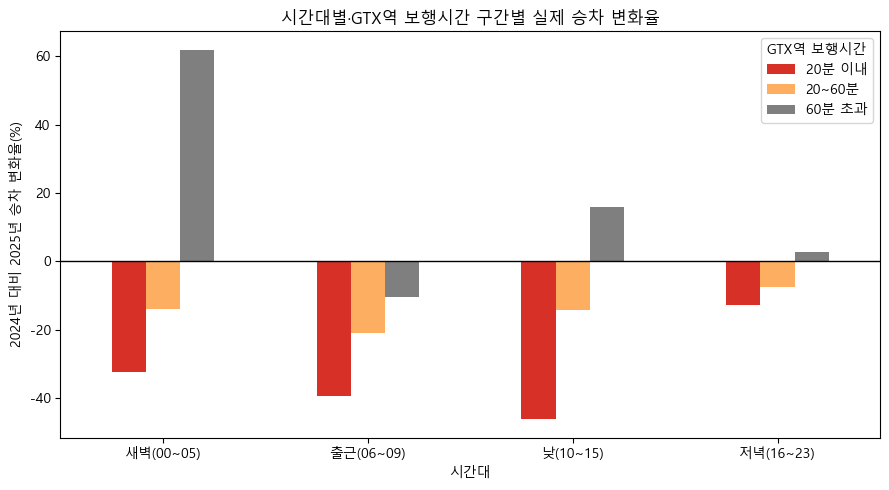

In [9]:
time_summary = (
    time_model.groupby(['시간대', 'walk_group'], observed=True)[['y2024_time', 'y2025_time']]
    .sum()
)
time_summary['실제 변화율(%)'] = np.where(
    time_summary['y2024_time'] > 0,
    (time_summary['y2025_time'] / time_summary['y2024_time'] - 1) * 100,
    np.nan,
)
time_rate_table = (
    time_summary['실제 변화율(%)'].unstack('walk_group')
    .reindex(TIME_LABELS)
)
display(time_rate_table.round(1))

ax = time_rate_table.plot.bar(
    figsize=(9, 5), rot=0, color=['#d73027', '#fdae61', '#7f7f7f']
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('시간대')
ax.set_ylabel('2024년 대비 2025년 승차 변화율(%)')
ax.set_title('시간대별·GTX역 보행시간 구간별 실제 승차 변화율')
ax.legend(title='GTX역 보행시간')
plt.tight_layout()
plt.show()

### 6-2. 시간대별 기본모형 OLS-HC3

In [10]:
time_fits = {}
time_rows = []
for time_label in TIME_LABELS:
    frame = time_model[time_model['시간대'] == time_label].dropna(
        subset=['change_time'] + BASE_FEATURES
    ).copy()
    X = sm.add_constant(frame[BASE_FEATURES].astype(float), has_constant='add')
    fit = sm.OLS(frame['change_time'], X).fit(cov_type='HC3')
    time_fits[time_label] = fit
    time_rows.append({
        '시간대': time_label,
        '셀 수': int(fit.nobs),
        '20분 이내 계수(명)': fit.params['walk_20'],
        '20분 이내 p값': fit.pvalues['walk_20'],
        '20~60분 계수(명)': fit.params['walk_20_60'],
        '20~60분 p값': fit.pvalues['walk_20_60'],
        'R²': fit.rsquared,
        '수정 R²': fit.rsquared_adj,
        '모형 전체 p값': fit.f_pvalue,
    })
time_result = pd.DataFrame(time_rows)
display(time_result.round(4))

,시간대,셀 수,20분 이내 계수(명),20분 이내 p값,20~60분 계수(명),20~60분 p값,R²,수정 R²,모형 전체 p값
0,새벽(00~05),132,-10.8351,0.0123,-4.2085,0.0068,0.1055,0.0626,0.0156
1,출근(06~09),132,-67.1078,0.0000,-20.9061,0.0120,0.1441,0.1030,0.0009
2,낮(10~15),132,-50.6895,0.0770,-10.4336,0.0137,0.1236,0.0815,0.0719
3,저녁(16~23),132,-18.4493,0.5671,-9.0320,0.1474,0.0530,0.0075,0.6906


### 6-3. 시간대별 보행시간 효과 시각화

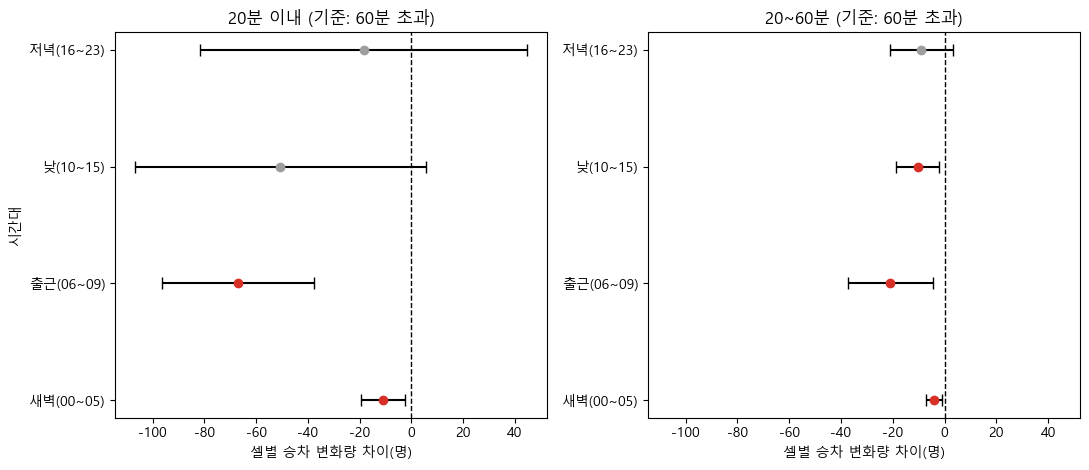

In [11]:
import matplotlib.pyplot as plt

plot_rows = []
for time_label, fit in time_fits.items():
    ci = fit.conf_int()
    for variable, group_label in [('walk_20', '20분 이내'), ('walk_20_60', '20~60분')]:
        plot_rows.append({
            '시간대': time_label,
            '구간': group_label,
            '계수': fit.params[variable],
            '하한': ci.loc[variable, 0],
            '상한': ci.loc[variable, 1],
            'p값': fit.pvalues[variable],
        })
plot_time = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True)
for ax, group_label in zip(axes, ['20분 이내', '20~60분']):
    part = plot_time[plot_time['구간'] == group_label].set_index('시간대').reindex(TIME_LABELS).reset_index()
    y = np.arange(len(part))
    x = part['계수'].to_numpy()
    xerr = np.vstack([x - part['하한'].to_numpy(), part['상한'].to_numpy() - x])
    colors = ['#d73027' if p < 0.05 else '#9e9e9e' for p in part['p값']]
    for idx in range(len(part)):
        ax.errorbar(x[idx], y[idx], xerr=[[xerr[0, idx]], [xerr[1, idx]]],
                    fmt='o', color=colors[idx], ecolor='black', capsize=4)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(part['시간대'])
    ax.set_title(group_label + ' (기준: 60분 초과)')
    ax.set_xlabel('셀별 승차 변화량 차이(명)')
axes[0].set_ylabel('시간대')
plt.tight_layout()
plt.show()

### 6-4. 시간대별 전체 변수 결과

각 시간대 모형에 포함된 6개 독립변수의 계수, HC3 표준오차, t값, p값과 모형 적합도를 모두 출력한다.

In [12]:
full_time_rows = []
for time_label, fit in time_fits.items():
    ci = fit.conf_int()
    for variable in BASE_FEATURES:
        full_time_rows.append({
            '시간대': time_label,
            '변수': labels[variable],
            '계수(명)': fit.params[variable],
            'HC3 표준오차': fit.bse[variable],
            't값': fit.tvalues[variable],
            'p값': fit.pvalues[variable],
            '95% CI 하한': ci.loc[variable, 0],
            '95% CI 상한': ci.loc[variable, 1],
            '유의성': ('***' if fit.pvalues[variable] < 0.01 else
                     '**' if fit.pvalues[variable] < 0.05 else
                     '*' if fit.pvalues[variable] < 0.10 else ''),
        })
full_time_result = pd.DataFrame(full_time_rows)
display(full_time_result.round(4))

print('시간대별 모형 적합도')
display(time_result[[
    '시간대', '셀 수', 'R²', '수정 R²', '모형 전체 p값'
]].round(4))

print('시간대별 변수 p값 비교')
pvalue_table = full_time_result.pivot(index='변수', columns='시간대', values='p값')
display(pvalue_table.reindex(columns=TIME_LABELS).round(4))

,시간대,변수,계수(명),HC3 표준오차,t값,p값,95% CI 하한,95% CI 상한,유의성
0,새벽(00~05),GTX역 보행 20분 이내(기준: 60분 초과),-10.8351,4.3287,-2.5031,0.0123,-19.3192,-2.3509,**
1,새벽(00~05),GTX역 보행 20~60분(기준: 60분 초과),-4.2085,1.5542,-2.7078,0.0068,-7.2546,-1.1623,***
2,새벽(00~05),IC까지 도로거리(km),-0.2473,0.2467,-1.0025,0.3161,-0.7308,0.2362,
3,새벽(00~05),GTX 경쟁 목적지 비율(%),-0.0369,0.0270,-1.3687,0.1711,-0.0898,0.0159,
4,새벽(00~05),2024년 20~50대 인구(명),-0.0002,0.0013,-0.1393,0.8892,-0.0028,0.0024,
5,새벽(00~05),2024년 건축물 수(동),-0.0139,0.0202,-0.6888,0.4909,-0.0535,0.0257,
6,출근(06~09),GTX역 보행 20분 이내(기준: 60분 초과),-67.1078,14.9940,-4.4757,0.0000,-96.4955,-37.7202,***
7,출근(06~09),GTX역 보행 20~60분(기준: 60분 초과),-20.9061,8.3249,-2.5113,0.0120,-37.2226,-4.5896,**
8,출근(06~09),IC까지 도로거리(km),-1.9881,1.1945,-1.6643,0.0960,-4.3293,0.3531,*
9,출근(06~09),GTX 경쟁 목적지 비율(%),-0.0893,0.1451,-0.6150,0.5385,-0.3737,0.1952,


시간대별 모형 적합도


,시간대,셀 수,R²,수정 R²,모형 전체 p값
0,새벽(00~05),132,0.1055,0.0626,0.0156
1,출근(06~09),132,0.1441,0.1030,0.0009
2,낮(10~15),132,0.1236,0.0815,0.0719
3,저녁(16~23),132,0.0530,0.0075,0.6906


시간대별 변수 p값 비교


시간대,새벽(00~05),출근(06~09),낮(10~15),저녁(16~23)
변수,,,,
2024년 20~50대 인구(명),0.8892,0.8690,0.4116,0.1744
2024년 건축물 수(동),0.4909,0.4623,0.3330,0.2357
GTX 경쟁 목적지 비율(%),0.1711,0.5385,0.4720,0.3098
GTX역 보행 20~60분(기준: 60분 초과),0.0068,0.0120,0.0137,0.1474
GTX역 보행 20분 이내(기준: 60분 초과),0.0123,0.0000,0.0770,0.5671
IC까지 도로거리(km),0.3161,0.0960,0.9678,0.9373


## 7. 기본모형 다중공선성 진단

기본모형에 포함된 6개 독립변수의 VIF와 상관계수 히트맵을 확인한다. 일반적으로 VIF가 10 이상이면 다중공선성을 의심하며, 엄격하게는 5를 기준으로 사용한다.

기본모형 독립변수 VIF


,변수,VIF,판단
0,GTX 보행 20~60분,1.532,문제 없음
1,IC까지 도로거리,1.459,문제 없음
2,GTX 보행 20분 이내,1.295,문제 없음
3,GTX 경쟁 목적지 비율,1.242,문제 없음
4,2024년 20~50대 인구,1.129,문제 없음
5,2024년 건축물 수,1.047,문제 없음


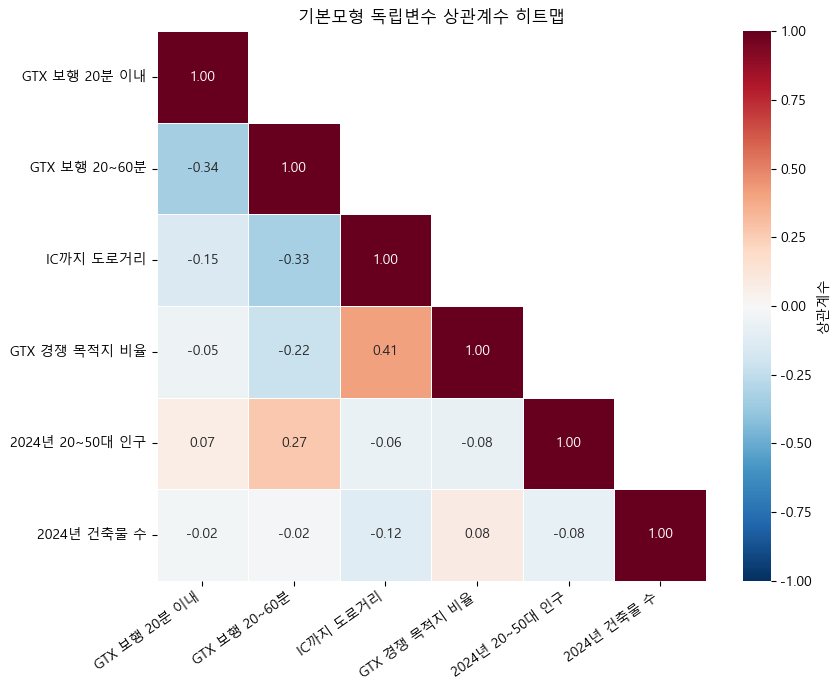

최대 VIF: 1.532


In [14]:
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_LABELS = {
    'walk_20': 'GTX 보행 20분 이내',
    'walk_20_60': 'GTX 보행 20~60분',
    'ic_access': 'IC까지 도로거리',
    'competing_share': 'GTX 경쟁 목적지 비율',
    'pop_20_50': '2024년 20~50대 인구',
    'buildings': '2024년 건축물 수',
}

vif_x = model[BASE_FEATURES].astype(float).dropna().copy()
vif_design = sm.add_constant(vif_x, has_constant='add')
vif_table = pd.DataFrame({
    '변수': [VIF_LABELS[v] for v in BASE_FEATURES],
    'VIF': [
        variance_inflation_factor(vif_design.to_numpy(), vif_design.columns.get_loc(v))
        for v in BASE_FEATURES
    ],
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_table['판단'] = np.select(
    [vif_table['VIF'] >= 10, vif_table['VIF'] >= 5],
    ['다중공선성 높음', '주의'],
    default='문제 없음',
)
print('기본모형 독립변수 VIF')
display(vif_table.round(3))

corr = vif_x.rename(columns=VIF_LABELS).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.6,
    cbar_kws={'label': '상관계수'}, ax=ax
)
ax.set_title('기본모형 독립변수 상관계수 히트맵')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('최대 VIF:', round(vif_table['VIF'].max(), 3))